In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import astropy
from astropy.io import fits
from astropy.visualization import ImageNormalize, MinMaxInterval, PercentileInterval, AsinhStretch, AsymmetricPercentileInterval, make_lupton_rgb
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.convolution import Gaussian2DKernel, convolve

from photutils.background import Background2D, MedianBackground
from photutils.segmentation import detect_sources, detect_threshold

import skimage as ski
from skimage.segmentation import inverse_gaussian_gradient, morphological_geodesic_active_contour
from skimage.measure import regionprops

from scipy import ndimage

# Extracción de datos RAW

In [2]:
fits_path = Path.cwd()/Path('FITS/1-338796_grz.fits')#FITS\1-115357_grz.fits
#open fits file
hdulist= fits.open(fits_path)
hdulist.info()
headers = fits.getheader(fits_path)
image_data= fits.getdata(fits_path)
hdulist.close()
    

Filename: c:\Users\jfmag\OneDrive\Documentos\Maestria\Proyecto integrador\FITS\1-338796_grz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      28   (800, 800, 3)   float32   


In [3]:
headers

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    3 / number of data axes                            
NAXIS1  =                  800 / length of data axis 1                          
NAXIS2  =                  800 / length of data axis 2                          
NAXIS3  =                    3 / length of data axis 3                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
SURVEY  = 'LegacySurvey'                                                        
VERSION = 'DR10    '                                                            
IMAGETYP= 'IMAGE   '           / None                                           
BANDS   = 'grz     '        

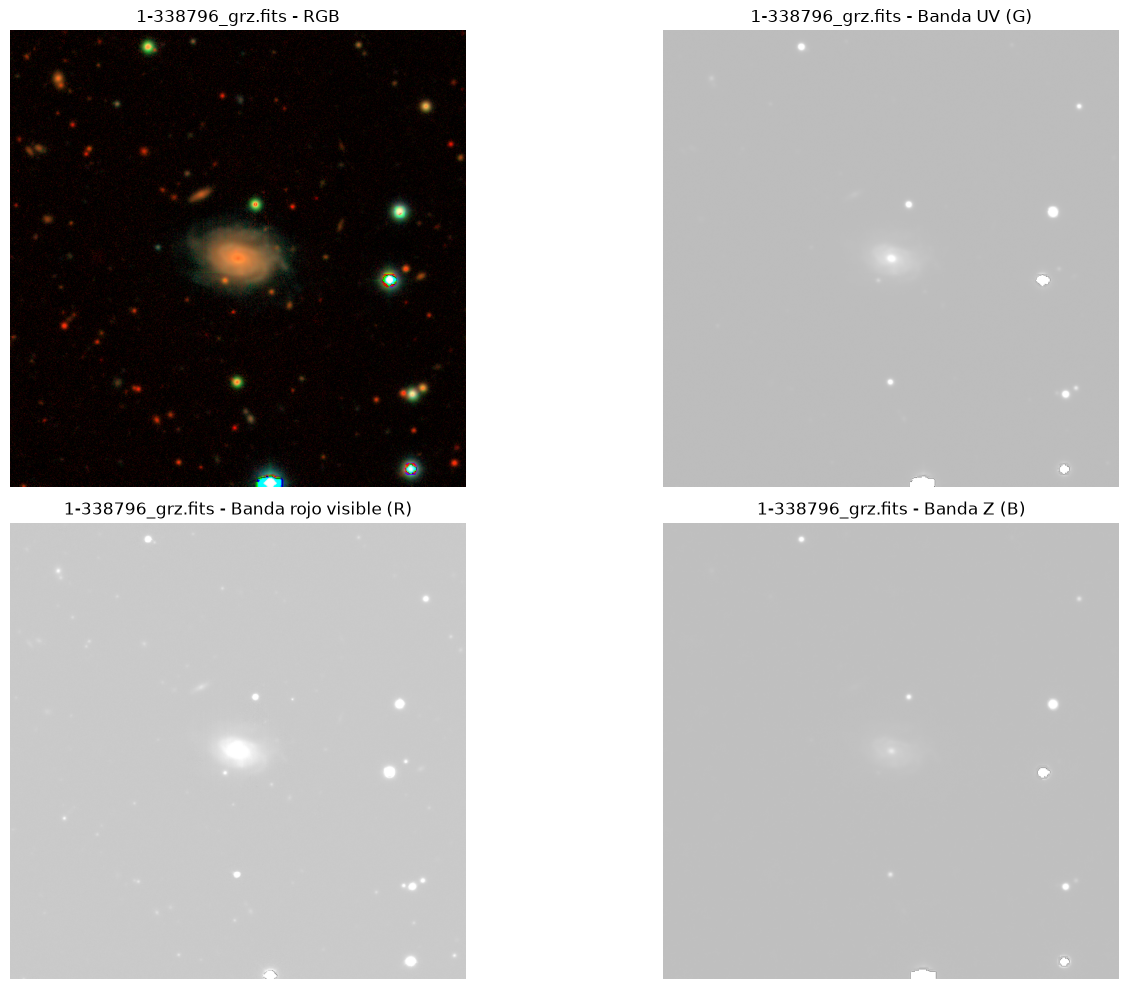

In [4]:
gal_rgb = make_lupton_rgb(image_r=image_data[2], image_g=image_data[1], image_b=image_data[0], stretch=0.1)
gal_r = image_data[2] #Banda Rojo visible - canal R
gal_g = image_data[1] #Banda UV - canal G
gal_b = image_data[0] #Banda Z - canal B

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15,10))
#rgb
luz_rgb = np.median(gal_rgb) + np.std(gal_rgb)*2
ax[0,0].imshow(gal_rgb, vmin=luz_rgb,  origin='lower')
ax[0,0].set_title(f'{os.path.split(fits_path)[1]} - RGB')
ax[0,0].axis('off')

luz_g = np.median(gal_g) + np.std(gal_g)*2
ax[0,1].imshow(gal_g, vmax=luz_g, vmin=np.min(image_data[1]),  origin='lower', cmap='grey')
ax[0,1].set_title(f'{os.path.split(fits_path)[1]} - Banda UV (G)')
ax[0,1].axis('off')

luz_r = np.median(gal_r) + np.std(gal_r)*2
ax[1,0].imshow(gal_r, vmax=luz_r, vmin=np.min(image_data[2]), origin='lower', cmap='grey')
ax[1,0].set_title(f'{os.path.split(fits_path)[1]} - Banda rojo visible (R)')
ax[1,0].axis('off')

luz_b = np.median(gal_b) + np.std(gal_b)*2
ax[1,1].imshow(gal_b, vmax=luz_b, vmin=np.min(image_data[0]), origin='lower', cmap='grey')
ax[1,1].set_title(f'{os.path.split(fits_path)[1]} - Banda Z (B)')
ax[1,1].axis('off')

plt.tight_layout()
plt.show()

# Aislamiento de la galaxia - efecto "cartulina negra"

## Cálculo de estadísticas con sigma_clipped_stats

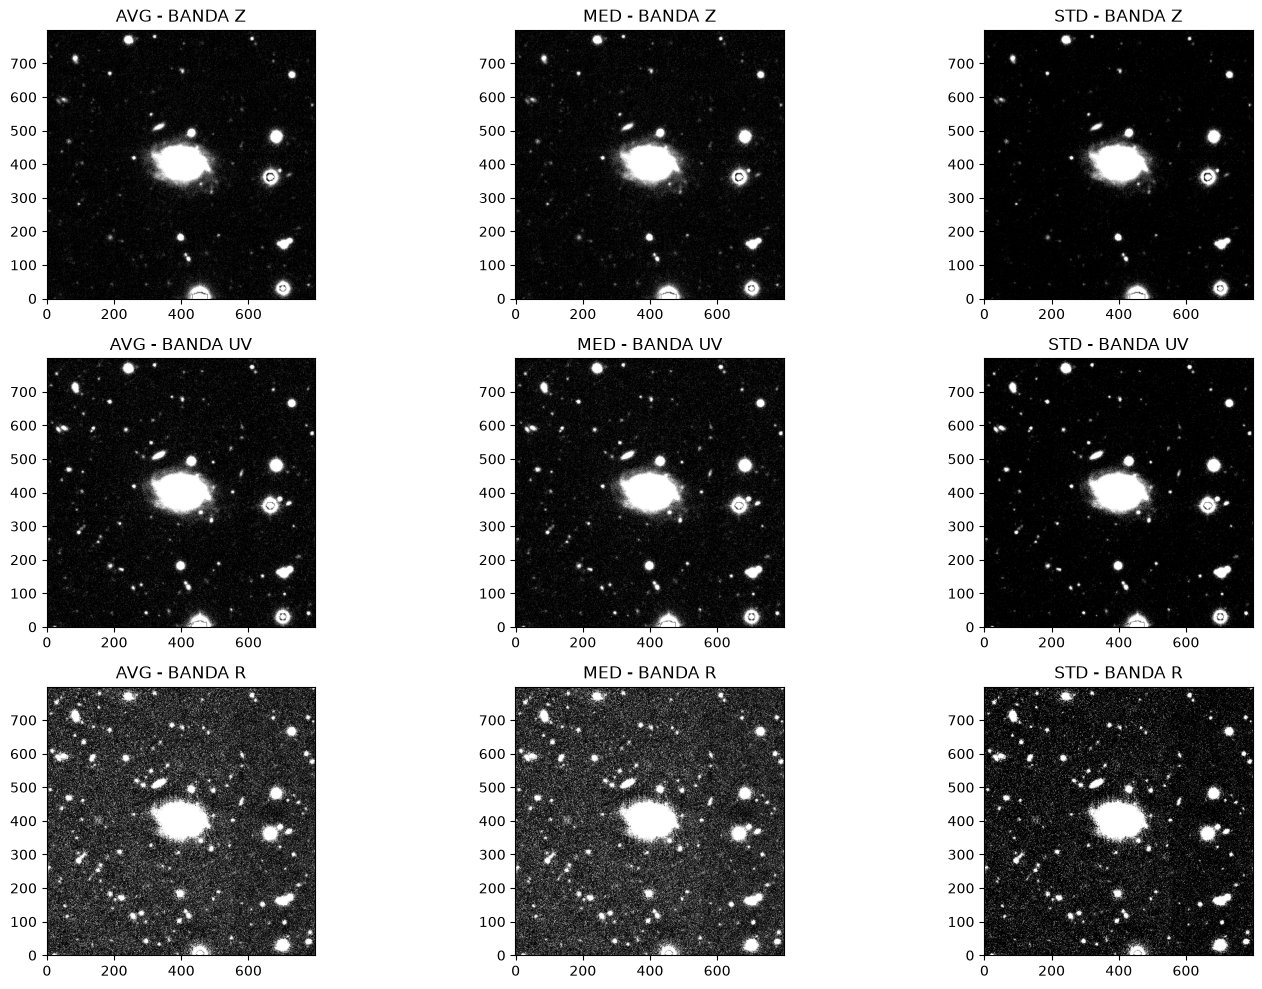

In [5]:
# Empaquetamos los canales y sus nombres
canales = [
    (gal_b, "BANDA Z"),
    (gal_g, "BANDA UV"),
    (gal_r, "BANDA R")
]

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15,10))

for i, (gal, nombre) in enumerate(canales):

    # Métricas sigma-clipped
    stats_clp = sigma_clipped_stats(data=gal, sigma=3.5, maxiters=10)

    # stats_clp = (mean, median, std)
    mean_val, med_val, std_val = stats_clp

    # Para cada métrica hacemos una columna
    métricas = [
        (mean_val, f"AVG - {nombre}"),
        (med_val,  f"MED - {nombre}"),
        (std_val,  f"STD - {nombre}")
    ]

    for j, (vmin_val, titulo) in enumerate(métricas):
        axs[i, j].imshow(gal, 
                         vmin=vmin_val, 
                         vmax=np.mean(gal),
                         cmap="gray",
                         origin="lower")
        axs[i, j].set_title(titulo)
        axs[i, j].axis("on")

plt.tight_layout()
plt.show()


## Estimación de métricas del background

In [2]:
def metricas_fondo (arreglo):
    '''
    El objetivo de la función es poder detectar el valor de fondo para cada canal de las diferentes imágenes.
    Pipeline:
        1. Obtener el box_size que es dato más importante para calcular el los "bloques" en los que se va a analizar al imagen.
            1. Cálculo d ela mediana con sigma_clipped_stats
            2. Uso regionprops, sirve para hacer varios segmentos de la imagen
            3. Obtengo el valor de axis_major_length, esto lo obtengo del valor que tenga la area más grande.
            4. Calculo el tamaño del box size y filter; dejo un valor fijo de alpha 5, lo anterior basado en que si aplico un alpha de 4 ó 6 tendría box muy grande o muy pequeño, perdiendo propiedades de la galaxia
            NOTA: EL BOX_SIZE y el FILTER requieren ser números impares
        2. Cálculo del valor del fondo (cielo astronómico).
            1. Implemento photutils.background.Background2D para obtener el valor del cielo astronómico.
    Return Empaqueto todos los resultados de los arreglos son ruido, la mediana de sigma_clipped_stats, y los arreglos de los backgrounds
    '''
    sc = SigmaClip(sigma=3.0)
    back_median = MedianBackground(sigma_clip=sc)

    for idx, array in enumerate(arreglo):
        #mediana
        #Métricas del cielo astronómico por canal
        sc_avg, sc_med, _ = sigma_clipped_stats(data=array,sigma=3.5, maxiters=10)
        #obtengo el regionprops
        reg_props = regionprops(np.astype(array,int))
        #obtención del tamaño del eje mas grande de una elipse que engloba la galaxia
        max_axis = [i.axis_major_length for i in reg_props if i.area == max([i.area for i in reg_props])][0] #resto 1 para tener el índice correcto, los labels están recorridos
        #tamaño box_size y filtros
        bs = int(np.round(max_axis / 5, 0))
        filters = int(np.round(2 * (bs / 20) + 1, 0))
        if bs %2 ==0: bs+=1
        if filters%2==0: filters +=1

        #cálculo del ruido por canal y recalculo los valores de los arreglos
        bkg = Background2D(array, box_size=(bs, bs), filter_size=(filters, filters), 
                sigma_clip=sc, bkg_estimator=back_median, filter_threshold=sc_avg)
        arr_cielo_canal = array - bkg.background

        #guardo el valor por cada canal
        if idx==0: #Banda Z - canal B
            arr_cielo_b = array
            sc_b = sc_med
            bkg_b= bkg
        elif idx==1: #Banda UV - canal G
            arr_cielo_g = array
            sc_g = sc_med
            bkg_g = bkg
        else: #Banda Rojo visible - canal R
            arr_cielo_r = arr_cielo_canal
            sc_r = sc_med
            bkg_r = bkg
    
    dict_datos = {
        "fits": np.stack([arr_cielo_b, arr_cielo_g, arr_cielo_r], axis=0),
        "cielo_med": {"r": sc_r, "g": sc_g, "b": sc_b},
        "bkgs": {"r": bkg_r, "g": bkg_g, "b": bkg_b},
    }
    return dict_datos



In [43]:
bkgs = metricas_fondo(image_data)

## Normalización de la imagen

In [3]:
def norm_fits (arr_galaxia_rgb):
    '''
    Descripción del pipeline:
        1. Cálculo de las métricas del cielo astronómico
        2. Cálculo de los valores alpha para los tipos de escalamiento (lupton, lupton estándar y estadístico)
        3. Instanciar los tipos de normalización de la imagen
        4. Normalización de la imagen
    RETURN arreglos y normalizaciones por canal

    NOTA: RECORDAR QUE SE RECIBEN 3 CANALES EN EL ARREGLO RGB
    '''
    for idx, arr in enumerate(arr_galaxia_rgb):
        # cálculo de valores alpha para hacer el AsinhStrech
        _, med_cielo, std_cielo = sigma_clipped_stats(arr, sigma=3, maxiters=10)
        denominador = np.max(arr)-np.min(arr)
        alpha_lupton= std_cielo/denominador
        alpha_lest = std_cielo*3
        alpha_est = (med_cielo-np.min(arr))/denominador

        #instancio los tipo de normalización
        minmax = MinMaxInterval()
        itqr = PercentileInterval(percentile=98)
        aprint = AsymmetricPercentileInterval(lower_percentile=1, upper_percentile=98)
        asin_lupton = AsinhStretch(a=alpha_lupton)
        asin_lest = AsinhStretch(a=alpha_lest)
        asin_est = AsinhStretch(a=alpha_est)

        #normalización con lupton
        minmax_lupton = ImageNormalize(data=arr,interval=minmax, stretch=asin_lupton)
        percent_lupton = ImageNormalize(data=arr,interval=itqr, stretch=asin_lupton)
        aprint_lupton = ImageNormalize(data=arr,interval=aprint, stretch=asin_lupton)
        #normalización con lupton estándar
        minmax_lest = ImageNormalize(data=arr,interval=minmax, stretch=asin_lest)
        percent_lest = ImageNormalize(data=arr,interval=itqr, stretch=asin_lest)
        aprint_lest = ImageNormalize(data=arr,interval=aprint, stretch=asin_lest)
        #normalización con estadítico
        minmax_est = ImageNormalize(data=arr,interval=minmax, stretch=asin_est)
        percent_est = ImageNormalize(data=arr,interval=itqr, stretch=asin_est)
        aprint_est = ImageNormalize(data=arr,interval=aprint, stretch=asin_est)

        if idx==0:
            b_minmax_lupton=minmax_lupton
            b_percent_lupton=percent_lupton
            b_aprint_lupton=aprint_lupton
            b_minmax_lest=minmax_lest
            b_percent_lest=percent_lest
            b_aprint_lest=aprint_lest
            b_minmax_est=minmax_est
            b_percent_est=percent_est
            b_aprint_est=aprint_est
        elif idx==1:
            g_minmax_lupton=minmax_lupton
            g_percent_lupton=percent_lupton
            g_aprint_lupton=aprint_lupton
            g_minmax_lest=minmax_lest
            g_percent_lest=percent_lest
            g_aprint_lest=aprint_lest
            g_minmax_est=minmax_est
            g_percent_est=percent_est
            g_aprint_est=aprint_est
        else:
            r_minmax_lupton=minmax_lupton
            r_percent_lupton=percent_lupton
            r_aprint_lupton=aprint_lupton
            r_minmax_lest=minmax_lest
            r_percent_lest=percent_lest
            r_aprint_lest=aprint_lest
            r_minmax_est=minmax_est
            r_percent_est=percent_est
            r_aprint_est=aprint_est

    return {
                "canal_b": {
                    "MinMax Lupton":b_minmax_lupton, "Percentile Lupton":b_percent_lupton, "Asym Per Lupton":b_aprint_lupton,
                    "MinMax Lupton Est":b_minmax_lest, "Percentile Lupton Est":b_percent_lest, "Asym Per Lup Est":b_aprint_lest,
                    "MinMax Est":b_minmax_est, "Percentile Est":b_percent_est, "Asym Per Est":b_aprint_est
                    },
                "canal_g": {
                    "MinMax Lupton":g_minmax_lupton, "Percentile Lupton":g_percent_lupton, "Asym Per Lupton":g_aprint_lupton,
                    "MinMax Lupton Est":g_minmax_lest, "Percentile Lupton Est":g_percent_lest, "Asym Per Lup Est":g_aprint_lest,
                    "MinMax Est":g_minmax_est, "Percentile Est":g_percent_est, "Asym Per Est":g_aprint_est
                    },
                "canal_r": {
                    "MinMax Lupton":r_minmax_lupton, "Percentile Lupton":r_percent_lupton, "Asym Per Lupton":r_aprint_lupton,
                    "MinMax Lupton Est":r_minmax_lest, "Percentile Lupton Est":r_percent_lest, "Asym Per Lup Est":r_aprint_lest,
                    "MinMax Est":r_minmax_est, "Percentile Est":r_percent_est, "Asym Per Est":r_aprint_est
                    },
            }
            

In [86]:
norm_imgs = norm_fits(bkgs['fits'])

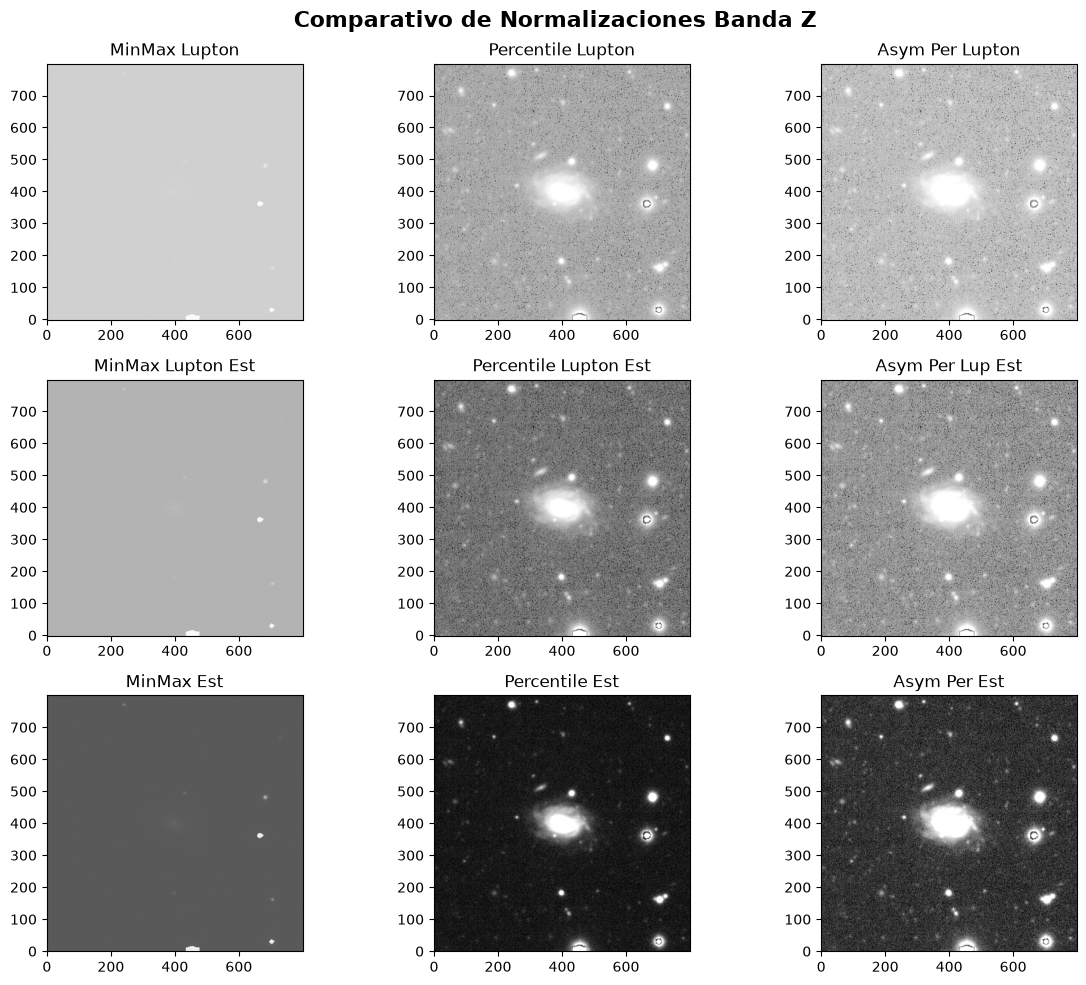

In [102]:
#gráficas banda Z normalizadas
fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(12,10))
axs = axs.ravel()
fig.suptitle('Comparativo de Normalizaciones Banda Z', fontsize=16, fontweight='bold')
for (k,v), ax in zip(norm_imgs['canal_b'].items(),axs):
    ax.imshow(bkgs['fits'][0], norm = v, origin='lower', cmap='grey')
    ax.set_title(f'{k}')

plt.tight_layout()
plt.show()

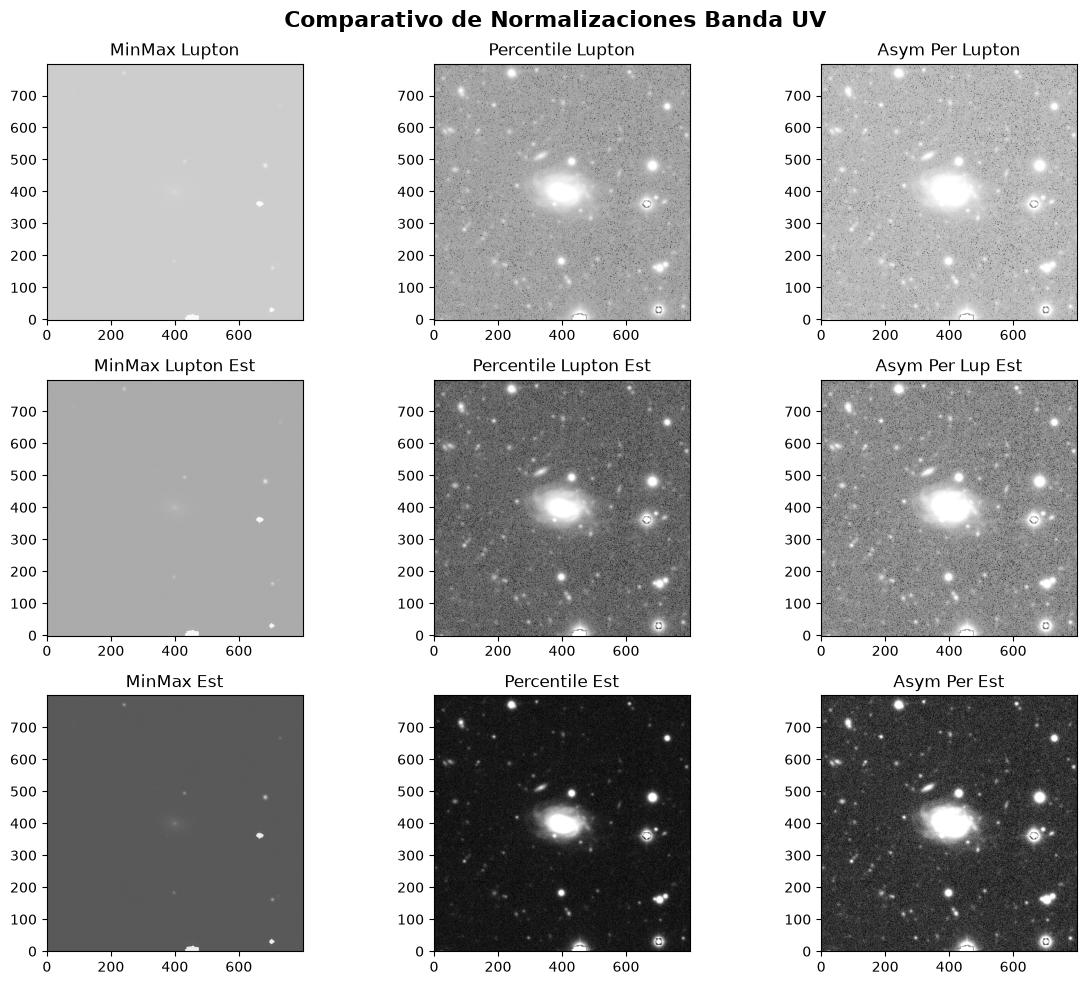

In [101]:
#gráficas banda UV normalizadas
fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(12,10))
axs = axs.ravel()
fig.suptitle('Comparativo de Normalizaciones Banda UV', fontsize=16, fontweight='bold')
for (k,v), ax in zip(norm_imgs['canal_g'].items(),axs):
    ax.imshow(bkgs['fits'][1], norm = v, origin='lower', cmap='grey')
    ax.set_title(f'{k}')

plt.tight_layout()
plt.show()

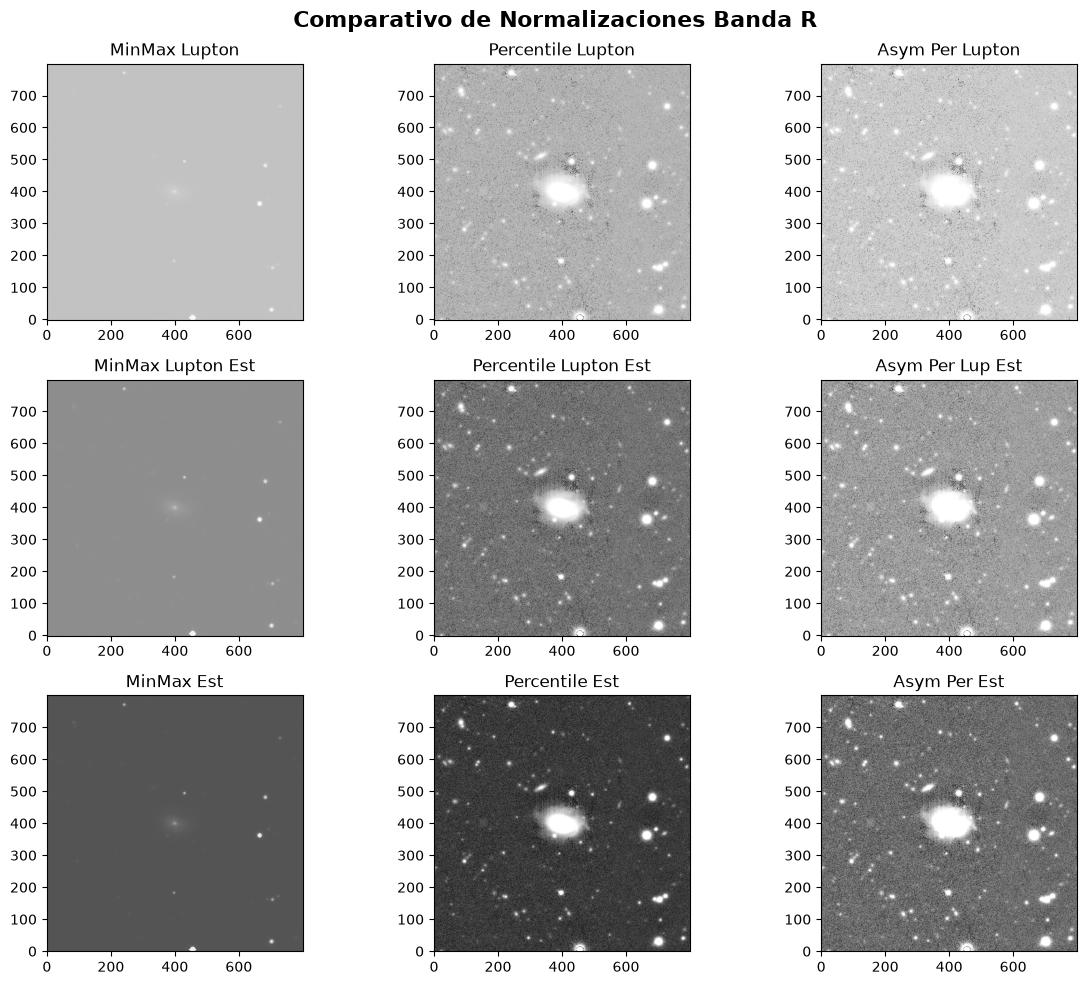

In [100]:
#gráficas banda R normalizadas
fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(12,10))
axs = axs.ravel()
fig.suptitle('Comparativo de Normalizaciones Banda R', fontsize=16, fontweight='bold')
for (k,v), ax in zip(norm_imgs['canal_r'].items(),axs):
    ax.imshow(bkgs['fits'][2], norm = v, origin='lower', cmap='grey')
    ax.set_title(f'{k}')

plt.tight_layout()
plt.show()

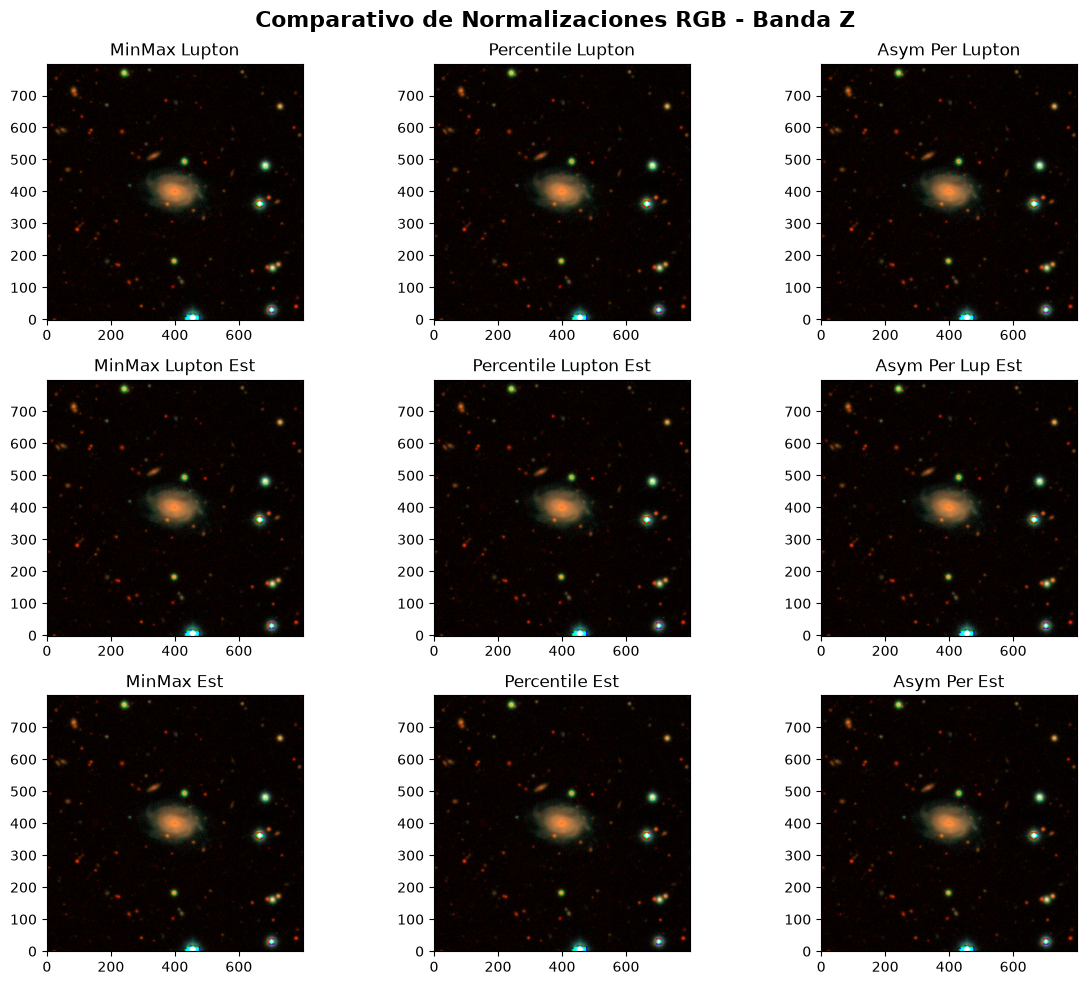

In [93]:
#gráficas RGB normalizadas
fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(12,10))
fig.suptitle('Comparativo de Normalizaciones RGB - Banda Z', fontsize=16, fontweight='bold')
axs = axs.ravel()

for (k,v), ax in zip(norm_imgs['canal_b'].items(),axs):
    ax.imshow(glx_rgb_sr, norm = v, origin='lower')
    ax.set_title(f'{k}')

plt.tight_layout()
plt.show()

## Implementación de máscara Gaussiana

In [4]:
def mascara_gaussiana(arreglo_rgb, nsigma, multiplo, stats, banda):
    '''
    Descripción del pipeline:
    1. Este proceso no aplica por canal, por lo que sólo se hace en un canal.
    1. Obtener la segmentación gaussina para separar la galaxia
    2. Elaborar la máscara booleana, este caso sólo se hace el cálculo bajo un solo canal
    Return el boolean mask, y el seg_gaus
    '''

    ## PASO 1:
    if banda=='Z':
        arr=arreglo_rgb[0]
    elif banda=='UV':
        arr=arreglo_rgb[1]
    else:
        arr=arreglo_rgb[2]

    ## PASO 2:
    #instancio los Kernels
    g2dK=Gaussian2DKernel(x_stddev=3, y_stddev=3)
    #convolusionamos la data
    convolve_Gauss = convolve(arr, g2dK)
    
    #detecta sources
    avg_u, med_u, std_u = sigma_clipped_stats(convolve_Gauss, sigma=3, maxiters=10)
    if stats==' avg':
        st= avg_u
    elif stats=='std':
        st=std_u
    else:
        st=med_u

    umbral = detect_threshold(convolve_Gauss,n_sigma=nsigma, error=st*multiplo)
    #segmento la imágen
    seg_gauss = detect_sources(data=convolve_Gauss, threshold=umbral, n_pixels=5, connectivity=8)
    
    ##PASO 3:
    # generar una boolean mask para prender la galaxia solamente
    arr_etiquetas= seg_gauss.data.ravel()
    arr_lbl= np.bincount(arr_etiquetas)
    arr_lbl[0]=0
    id_galaxia=(np.argmax(arr_lbl))
    bm_galaxia = seg_gauss.data == id_galaxia

    return bm_galaxia, seg_gauss

In [116]:
#mascara_gaussiana(arreglo_rgb, nsigma, multiplo, stats, banda)
mascara = mascara_gaussiana(bkgs['fits'], nsigma=18, multiplo=5, stats = 'med', banda='Z')

Text(0.5, 1.0, 'Máscara booleana')

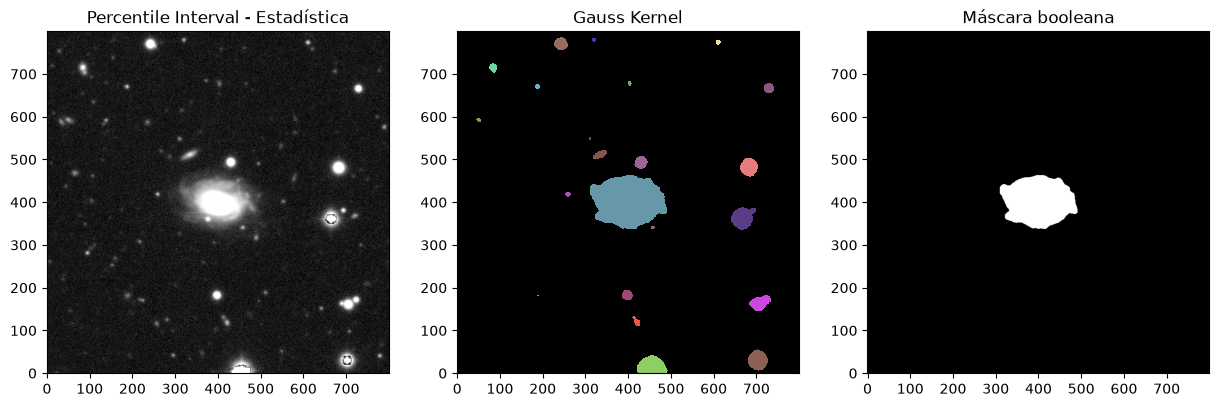

In [117]:
#grafico la segmentación de la galaxia
fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(15,10))
axs[0].imshow(bkgs['fits'][1], origin='lower', cmap="grey", norm = norm_imgs['canal_g']['Percentile Est'])
axs[0].set_title('Percentile Interval - Estadística')
mascara[1].imshow(ax=axs[1])
axs[1].set_title('Gauss Kernel')
axs[2].imshow(mascara[0], cmap='grey', origin='lower')
axs[2].set_title('Máscara booleana')

## Limpieza de estrellas - "cartulina negra"

In [6]:
def limpieza_estrellas(arreglo_rgb, backgrounds, mask):
    '''
    Descripción del pipeline:
    1. Cáculo del STD con sigma_clipped_stats
    2. Convertir todos aquellos valores que no pertenecen a la galaxia al valor de STD
    RETURN por canal con el nuevo fondo sin tocar la galaxia

    NOTA: Esto se hace por canal
    '''
    #"bkgs": {"r": bkg_r, "g": bkg_g, "b": bkg_b},
    for idx, arr in enumerate(arreglo_rgb):
        if idx==0:
            bkg= backgrounds.get('b')
        elif idx==1:
            bkg= backgrounds.get('g')
        else:
            bkg= backgrounds.get('r')

        _,_,std_bkg = sigma_clipped_stats(bkg.background_rms, sigma=3, maxiters=10) 
        glx_lim = np.copy(a=arr)
        glx_lim = np.where(~mask, std_bkg, glx_lim)

        if idx==0:
            glx_b= glx_lim
        elif idx==1:
            glx_g= glx_lim
        else:
            glx_r= glx_lim

    return np.stack([glx_b, glx_g, glx_r], axis=0)

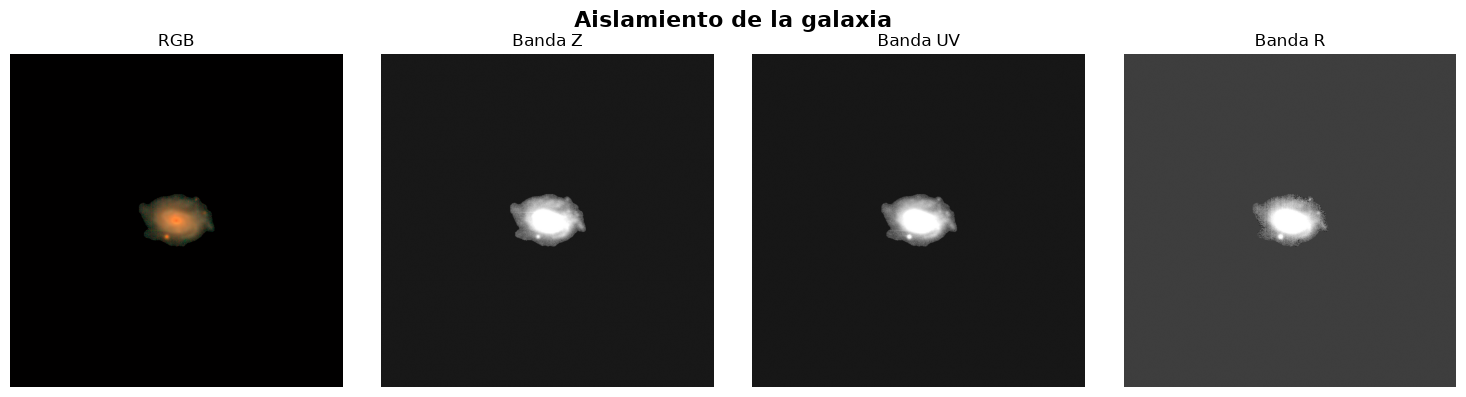

In [132]:
glx = limpieza_estrellas()
glx_rgb = make_lupton_rgb(image_r=glx[2], image_g=glx[1], image_b=glx[0], stretch=0.1)

fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(15,4))
fig.suptitle('Aislamiento de la galaxia', fontsize=16, fontweight='bold')
axs[0].imshow(glx_rgb, origin='lower', norm = norm_imgs['canal_b']['Percentile Est'])
axs[0].set_title('RGB')
axs[0].axis('off')
axs[1].imshow(glx[0], origin='lower', norm = norm_imgs['canal_b']['Percentile Est'], cmap='grey')
axs[1].set_title('Banda Z')
axs[1].axis('off')
axs[2].imshow(glx[1], origin='lower', norm = norm_imgs['canal_g']['Percentile Est'], cmap='grey')
axs[2].set_title('Banda UV')
axs[2].axis('off')
axs[3].imshow(glx[2], origin='lower', norm = norm_imgs['canal_r']['Percentile Est'], cmap='grey')
axs[3].set_title('Banda R')
axs[3].axis('off')

plt.tight_layout()
plt.show()

# Image segmentation - Spline

In [7]:
def max_luz_spline (glx_limpia, norm_type, mask):
    '''
    Descripción del pipeline:
    1. Se invoca la función de normalización por banda, y sólo se quedan por default las minmax
    2. Se aplica inverse_gaussian_gradient para poder delimitar los bordes de la galaxia
    3. Otener el arreglo del spline con morphological_geodesic_active_contour
    4. Se obtiene la máscara binanria
    RETURN spline y máscara binaria, y normalización

    NOTA: SÓLO AL PASO 1 SE APLICA A LOS 3 CANALES, EL RESTO DE LOS PASOS SÓLO SE APLICA A UN SOLO CANAL, POR DEFAULT SERÁ UV
    '''
    #PASO 1 / el ideal es que al construir la clase se invoque la función
    for arr in glx_limpia:
        # cálculo de valores alpha para hacer el AsinhStrech
        _, med_cielo, std_cielo = sigma_clipped_stats(arr, sigma=3, maxiters=10)
        denominador = np.max(arr)-np.min(arr)
        alpha_lupton= std_cielo/denominador
        alpha_lest = std_cielo*3
        

        #instancio los tipo de normalización
        minmax = MinMaxInterval()
        asin_lupton = AsinhStretch(a=alpha_lupton)
        asin_lest = AsinhStretch(a=alpha_lest)

        if norm_type =='Lupton':
            b_minmax = ImageNormalize(data=arr,interval=minmax, stretch=asin_lupton)
            g_minmax = ImageNormalize(data=arr,interval=minmax, stretch=asin_lupton)
            r_minmax = ImageNormalize(data=arr,interval=minmax, stretch=asin_lupton)
        elif norm_type == 'Lupton Est':
            b_minmax = ImageNormalize(data=arr,interval=minmax, stretch=asin_lest)
            g_minmax = ImageNormalize(data=arr,interval=minmax, stretch=asin_lest)
            r_minmax = ImageNormalize(data=arr,interval=minmax, stretch=asin_lest)

    #PASO 2
    arr_invgaus = inverse_gaussian_gradient(image=g_minmax(glx_limpia[1]))
    #PASO 3
    snk_MGAC = morphological_geodesic_active_contour(
        gimage=arr_invgaus,
        num_iter=10,
        init_level_set=mask,
        threshold=0.1,
        balloon=0.2,
        smoothing=2,
    )
    #PASO 4
    mask_snk=ndimage.binary_fill_holes(snk_MGAC)
    mask_nn = mask_snk.astype(np.float32) # máscara para la neural network
    mask_cont = mask_snk.astype(np.int8) # spline para graficar

    return {
        'norms': {'b': b_minmax, 'g': g_minmax, 'r': r_minmax},
        'inverse_gausse': arr_invgaus,
        'snk_mgac': snk_MGAC,
        'mask_nn':mask_nn,
        'mask_cont':mask_cont
    }

In [179]:
glx_final = max_luz_spline()

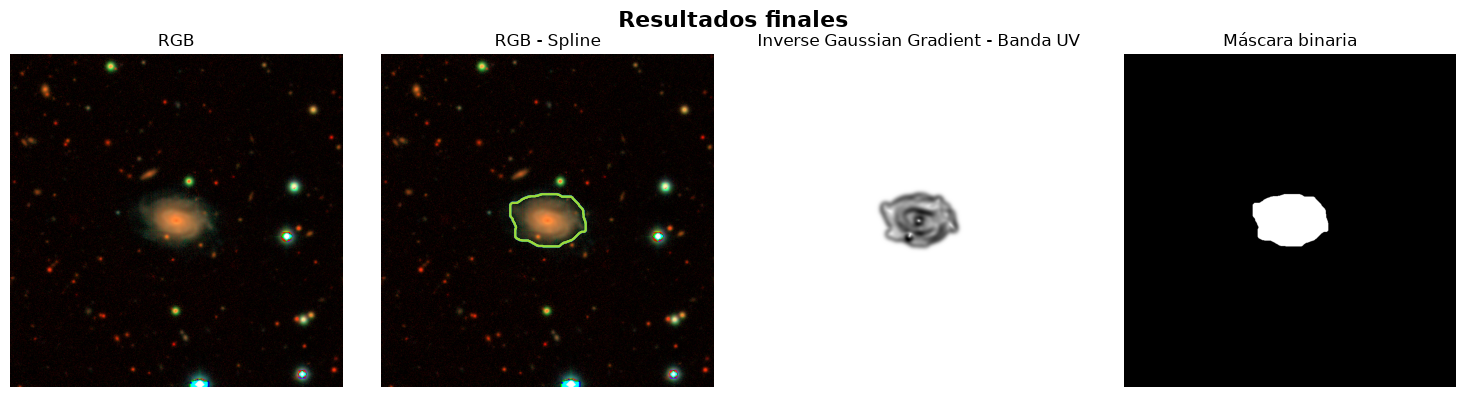

In [182]:
fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(15,4))
fig.suptitle('Resultados finales', fontsize=16, fontweight='bold')
axs[0].imshow(gal_rgb, origin='lower', norm = glx_final['norms']['g'])
axs[0].set_title('RGB')
axs[0].axis('off')
axs[1].imshow(gal_rgb, origin='lower', norm = glx_final['norms']['g'])
axs[1].contour(glx_final['mask_cont'])
axs[1].set_title('RGB - Spline')
axs[1].axis('off')
axs[2].imshow(glx_final['inverse_gausse'], cmap='grey', origin='lower' )
axs[2].set_title('Inverse Gaussian Gradient - Banda UV')
axs[2].axis('off')
axs[3].imshow(glx_final['mask_cont'], origin='lower', cmap='grey')
axs[3].set_title('Máscara binaria')
axs[3].axis('off')

plt.tight_layout()
plt.show()


# Prueba de generalización FITS

In [ ]:
fits_files=os.listdir(Path.cwd()/Path('FITS'))
fits_path = Path.cwd()/Path('FITS')
for f in fits_files:
    pf = fits_path/Path(f)
    # extracción del ID de la galaxia
    gname=f.split(sep="_")[0]
    #creación de folder
    pdir = Path(f'{fits_path}\{gname}')
    if not os.path.exists(pdir): os.mkdir(pdir)

    # extracción de datos del archivo fits
    hdulist= fits.open(pf)
    headers = fits.getheader(pf)
    image_data= fits.getdata(pf)
    hdulist.close()
    # graficas RAW
    gal_rgb = make_lupton_rgb(image_r=image_data[2], image_g=image_data[1], image_b=image_data[0], stretch=0.1)
    luz_rgb = np.median(gal_rgb) + np.std(gal_rgb)*2
    luz_g = np.median(image_data[1]) + np.std(image_data[1])*2
    luz_r = np.median(image_data[2]) + np.std(image_data[2])*2
    luz_b = np.median(image_data[0]) + np.std(image_data[0])*2
    fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(15,4))
    fig.suptitle(f'Imágenes RAW - {gname}', fontsize=16, fontweight='bold')
    ax[0].imshow(gal_rgb, vmin=luz_rgb,  origin='lower')
    ax[0].set_title(f'RGB')
    ax[0].axis('off')
    ax[1].imshow(image_data[0], vmax=luz_b, vmin=np.min(image_data[0]), origin='lower', cmap='grey')
    ax[1].set_title(f'Banda Z (B)')
    ax[1].axis('off')
    ax[2].imshow(image_data[1], vmax=luz_g, vmin=np.min(image_data[1]),  origin='lower', cmap='grey')
    ax[2].set_title(f'Banda UV (G)')
    ax[2].axis('off')
    ax[3].imshow(image_data[2], vmax=luz_r, vmin=np.min(image_data[2]), origin='lower', cmap='grey')
    ax[3].set_title(f'Banda R (R)')
    ax[3].axis('off')
    plt.tight_layout()
    plt.savefig(fname=f'{pdir}\RAW_IMG_{gname}.jpg',dpi=300, bbox_inches='tight')
    plt.close(fig)


    #Aislamiento de la galaxia
    bkgs = metricas_fondo(image_data)
    norm_imgs = norm_fits(bkgs['fits'])
    glx_rgb_norm = make_lupton_rgb(image_r=norm_imgs['canal_r'], image_g=norm_imgs['canal_g'], image_b=norm_imgs['canal_b'], stretch=0.1)
    #gráficas banda Z normalizadas
    fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(12,10))
    axs = axs.ravel()
    fig.suptitle('Comparativo de Normalizaciones Banda Z', fontsize=16, fontweight='bold')
    for (k,v), ax in zip(norm_imgs['canal_b'].items(),axs):
        ax.imshow(bkgs['fits'][0], norm = v, origin='lower', cmap='grey')
        ax.set_title(f'{k}')
    plt.tight_layout()
    plt.savefig(fname=f'{pdir}\Norm_Banda_Z_{gname}.jpg',dpi=300, bbox_inches='tight')
    plt.close(fig)
    #gráficas banda UV normalizadas
    fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(12,10))
    axs = axs.ravel()
    fig.suptitle('Comparativo de Normalizaciones Banda UV', fontsize=16, fontweight='bold')
    for (k,v), ax in zip(norm_imgs['canal_g'].items(),axs):
        ax.imshow(bkgs['fits'][1], norm = v, origin='lower', cmap='grey')
        ax.set_title(f'{k}')
    plt.tight_layout()
    plt.savefig(fname=f'{pdir}\Norm_Banda_UV_{gname}.jpg',dpi=300, bbox_inches='tight')
    plt.close(fig)
    #gráficas banda R normalizadas
    fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(12,10))
    axs = axs.ravel()
    fig.suptitle('Comparativo de Normalizaciones Banda R', fontsize=16, fontweight='bold')
    for (k,v), ax in zip(norm_imgs['canal_r'].items(),axs):
        ax.imshow(bkgs['fits'][2], norm = v, origin='lower', cmap='grey')
        ax.set_title(f'{k}')
    plt.tight_layout()
    plt.savefig(fname=f'{pdir}\Norm_Banda_R_{gname}.jpg',dpi=300, bbox_inches='tight')
    plt.close(fig)
    #gráficas RGB normalizadas
    fig, axs = plt.subplots(nrows=3,ncols=3,figsize=(12,10))
    fig.suptitle('Comparativo de Normalizaciones RGB - Banda Z', fontsize=16, fontweight='bold')
    axs = axs.ravel()
    for (k,v), ax in zip(norm_imgs['canal_b'].items(),axs):
        ax.imshow(glx_rgb_norm, norm = v, origin='lower')
        ax.set_title(f'{k}')
    plt.tight_layout()
    plt.savefig(fname=f'{pdir}\Norm_RGB_{gname}.jpg',dpi=300, bbox_inches='tight')
    plt.close(fig)

    #máscara Gaussiana
    mascara = mascara_gaussiana(bkgs['fits'], nsigma=18, multiplo=5, stats = 'med', banda='Z')
    #grafico la segmentación de la galaxia
    fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(15,10))
    axs[0].imshow(bkgs['fits'][1], origin='lower', cmap="grey", norm = norm_imgs['canal_g']['Percentile Est'])
    axs[0].set_title('Percentile Interval - Estadística')
    mascara[1].imshow(ax=axs[1])
    axs[1].set_title('Gauss Kernel')
    axs[2].imshow(mascara[0], cmap='grey', origin='lower')
    axs[2].set_title('Máscara booleana')
    plt.tight_layout()
    plt.savefig(fname=f'{pdir}\mascara_Gauss_{gname}.jpg',dpi=300, bbox_inches='tight')
    plt.close(fig)

    #limpieza de estrellas
    glx = limpieza_estrellas(bkgs['fits'], bkgs['bkgs'], mascara[0])
    glx_rgb = make_lupton_rgb(image_r=glx[2], image_g=glx[1], image_b=glx[0], stretch=0.1)
    fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(15,4))
    fig.suptitle('Aislamiento de la galaxia', fontsize=16, fontweight='bold')
    axs[0].imshow(glx_rgb, origin='lower', norm = norm_imgs['canal_b']['Percentile Est'])
    axs[0].set_title('RGB')
    axs[0].axis('off')
    axs[1].imshow(glx[0], origin='lower', norm = norm_imgs['canal_b']['Percentile Est'], cmap='grey')
    axs[1].set_title('Banda Z')
    axs[1].axis('off')
    axs[2].imshow(glx[1], origin='lower', norm = norm_imgs['canal_g']['Percentile Est'], cmap='grey')
    axs[2].set_title('Banda UV')
    axs[2].axis('off')
    axs[3].imshow(glx[2], origin='lower', norm = norm_imgs['canal_r']['Percentile Est'], cmap='grey')
    axs[3].set_title('Banda R')
    axs[3].axis('off')
    plt.tight_layout()
    plt.savefig(fname=f'{pdir}\limpieza_estrellas_{gname}.jpg',dpi=300, bbox_inches='tight')
    plt.close(fig)

    #IMAGE SEGMENTATION
    glx_final = max_luz_spline(glx, 'Lupton', mascara[0])
    fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(15,4))
    fig.suptitle('Resultados finales', fontsize=16, fontweight='bold')
    axs[0].imshow(gal_rgb, origin='lower', norm = glx_final['norms']['g'])
    axs[0].set_title('RGB')
    axs[0].axis('off')
    axs[1].imshow(gal_rgb, origin='lower', norm = glx_final['norms']['g'])
    axs[1].contour(glx_final['mask_cont'])
    axs[1].set_title('RGB - Spline')
    axs[1].axis('off')
    axs[2].imshow(glx_final['inverse_gausse'], cmap='grey', origin='lower' )
    axs[2].set_title('Inverse Gaussian Gradient - Banda UV')
    axs[2].axis('off')
    axs[3].imshow(glx_final['mask_cont'], origin='lower', cmap='grey')
    axs[3].set_title('Máscara binaria')
    axs[3].axis('off')
    plt.tight_layout()
    plt.savefig(fname=f'{pdir}\img_seg_{gname}.jpg',dpi=300, bbox_inches='tight')
    plt.close(fig)
